# Degus analisis espacial

DEBUG TOMI 0.019999999999999997
-> graficando s=2, t=3, c=3. disparos: 890
-> disparos tras filtro de velocidad (> 2 cm/s): 848


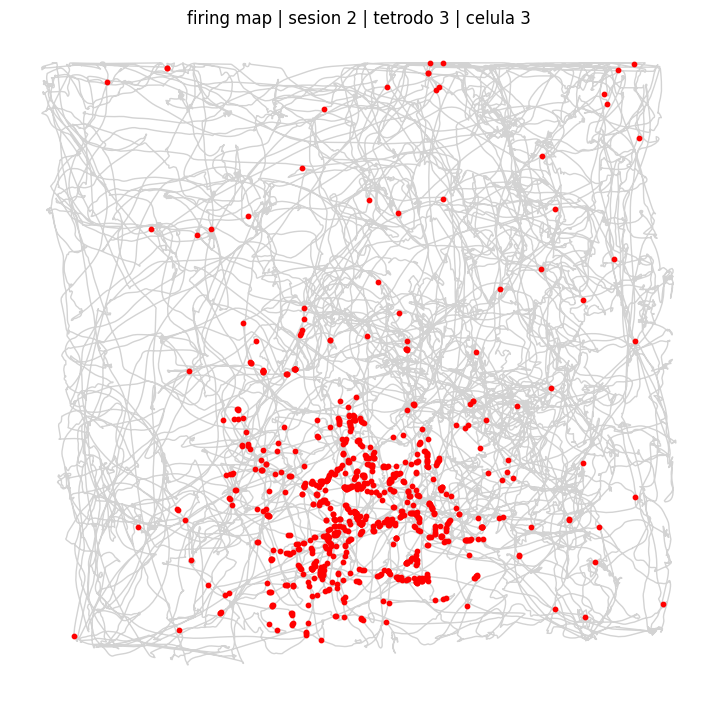

In [1]:
# Imports

%matplotlib inline
import os
import matplotlib.pyplot as plt

from scripts.utils import (
    firing_map, rate_map,
    get_gam_posicion, graficar_gam_posicion, glm_posicion_manual,
    get_gam_viewpoint_1d, graficar_gam_viewpoint_1d
)

## 1. Firing Map
Trayectoria completa y puntos donde disparó la neurona.

DEBUG TOMI 0.019999999999999997
-> graficando s=2, t=3, c=3. disparos: 890
-> disparos tras filtro de velocidad (> 2 cm/s): 848


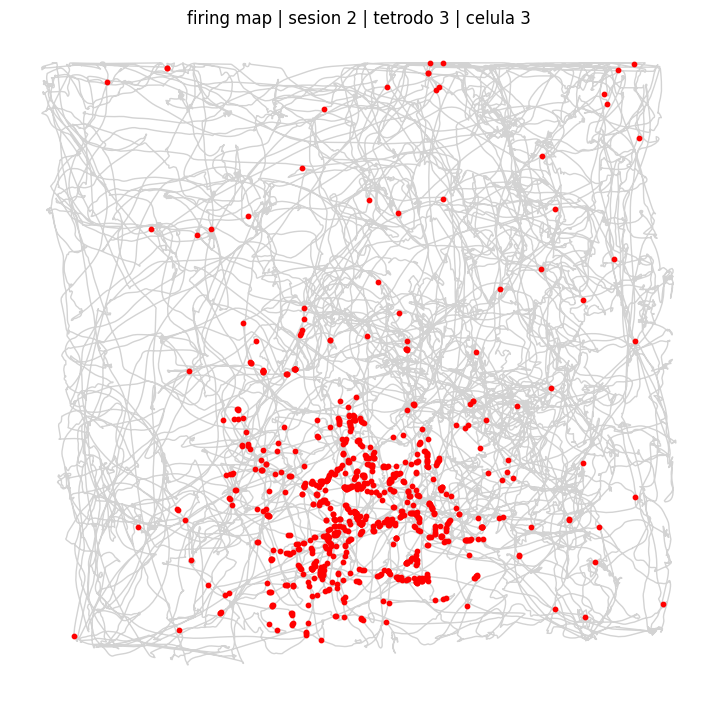

In [ ]:
sesion, tetrodo, neurona = 2, 3, 3
bin_size = 0.1

firing_map(sesion, tetrodo, neurona)

## 2. GLM Posición


--- INICIANDO GLM MANUAL DE POSICIÓN ---
DEBUG TOMI 0.019999999999999997
Construyendo Basis Functions (Grilla de 20x20 Campanas Gauss)...
¡Modelo entrenado (y regularizado)!


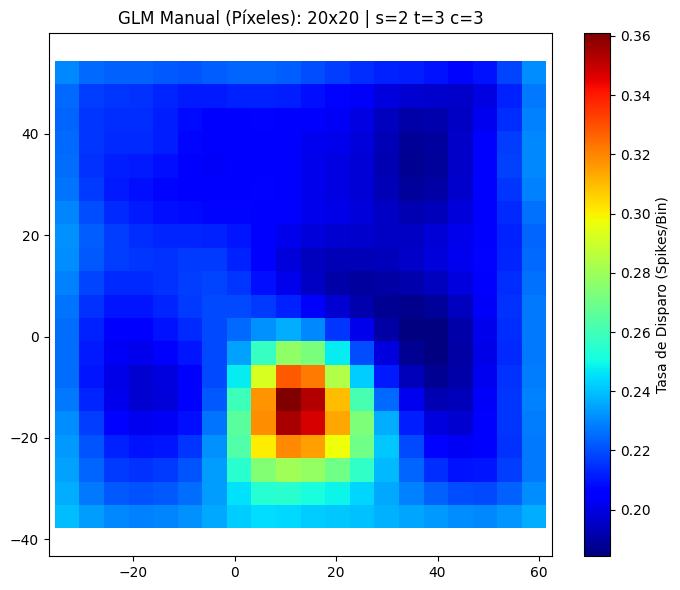

In [3]:
n_bines_glm = 20

glm_posicion_manual(sesion, tetrodo, neurona, n_bines_glm)

## 3. GAM Espacial (Place Cells)
Modela la respuesta de la neurona puramente a la posición (X, Y) usando splines.

DEBUG TOMI 0.019999999999999997
[+] Cargando GAM Posición guardado desde modelo_gam_pos_s2_t3_n3_sp5.pkl...

=== RESUMEN GAM POSICIÓN ===
PoissonGAM                                                                                                
=============================================== ==========================================================
Distribution:                       PoissonDist Effective DoF:                                     14.2791
Link Function:                          LogLink Log Likelihood:                                 -2392.8672
Number of Samples:                        11952 AIC:                                             4814.2927
                                                AICc:                                            4814.3344
                                                UBRE:                                               2.3118
                                                Scale:                                                 1.0
      

c:\Users\tomas\OneDrive\Escritorio\Octodon-Degus\scripts\utils\modeling.py:95: UserWarning: KNOWN BUG: p-values computed in this summary are likely much smaller than they should be. 
 
Please do not make inferences based on these values! 

Collaborate on a solution, and stay up to date at: 
github.com/dswah/pyGAM/issues/163 

  modelo_gam.summary()


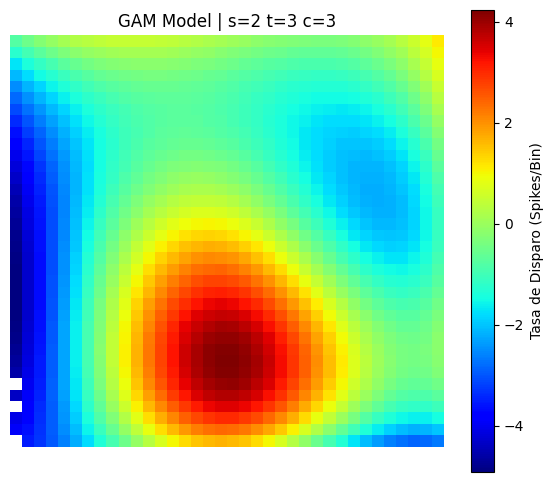

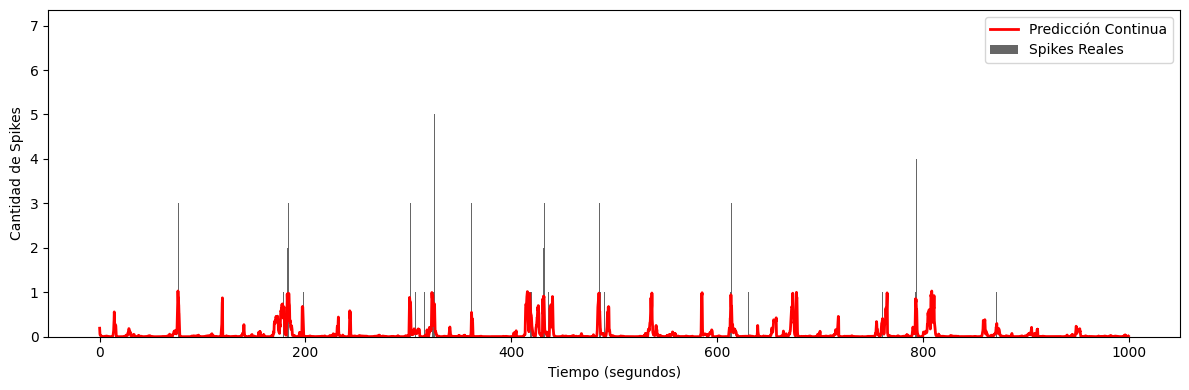

In [4]:
splines_pos = 5

# Obtenemos el modelo (lo entrena si es la primera vez o lo carga de caché)
modelo_pos, X_pos, Y_pos = get_gam_posicion(sesion, tetrodo, neurona, splines_pos, bin_size)

# Graficamos los resultados
graficar_gam_posicion(modelo_pos, X_pos, Y_pos, sesion, tetrodo, neurona, splines_pos, bin_size_sec=bin_size)

## 4. GAM Viewpoint (Mirada / Paredes)
Desenrolla la caja y calcula la respuesta hacia la mirada del animal usando GAMs 1D.

DEBUG TOMI 0.019999999999999997
[+] Cargando GAM Viewpoint 1D desde modelo_gam_vp1d_s2_t3_n3_sp20.pkl...

=== RESUMEN GAM VIEWPOINT 1D ===
PoissonGAM                                                                                                
=============================================== ==========================================================
Distribution:                       PoissonDist Effective DoF:                                     18.5316
Link Function:                          LogLink Log Likelihood:                                 -3307.7753
Number of Samples:                        10699 AIC:                                             6652.6138
                                                AICc:                                            6652.6889
                                                UBRE:                                               2.5262
                                                Scale:                                                 1.0
     

c:\Users\tomas\OneDrive\Escritorio\Octodon-Degus\scripts\utils\modeling.py:163: UserWarning: KNOWN BUG: p-values computed in this summary are likely much smaller than they should be. 
 
Please do not make inferences based on these values! 

Collaborate on a solution, and stay up to date at: 
github.com/dswah/pyGAM/issues/163 

  modelo_gam.summary()


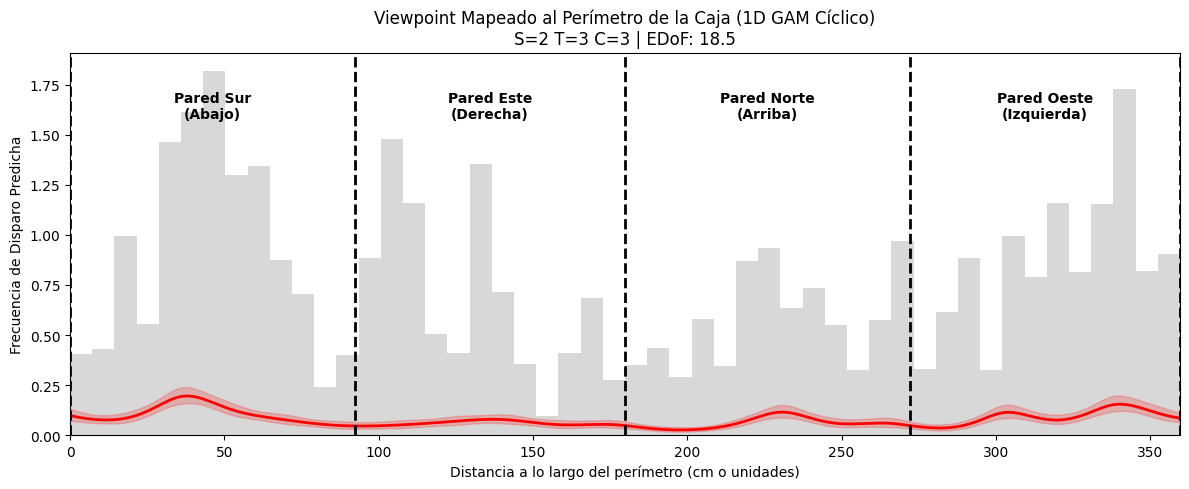

In [5]:
splines_vp = 20

# Obtenemos el modelo (lo entrena si es la primera vez o lo carga de caché)
modelo_vp, X_vp, Y_vp, W, H = get_gam_viewpoint_1d(sesion, tetrodo, neurona, splines_vp, bin_size)

# Graficamos los resultados
graficar_gam_viewpoint_1d(modelo_vp, X_vp, Y_vp, W, H, sesion, tetrodo, neurona)